CNN Music Classifer Model

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import librosa

# Sklean
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from keras import layers, optimizers, regularizers, callbacks, models

2.21.0
3.14.0


In [3]:
# Load in Train, Test, and Val Datasets
train_ds = np.load('train.npz')
test_ds = np.load('test.npz')
val_ds = np.load('val.npz')

In [4]:
# Separate Spectrograms from Labels
X_train = train_ds['X']
y_train = train_ds['y']

X_val = val_ds['X']
y_val = val_ds['y']

X_test = test_ds['X']
y_test = test_ds['y']

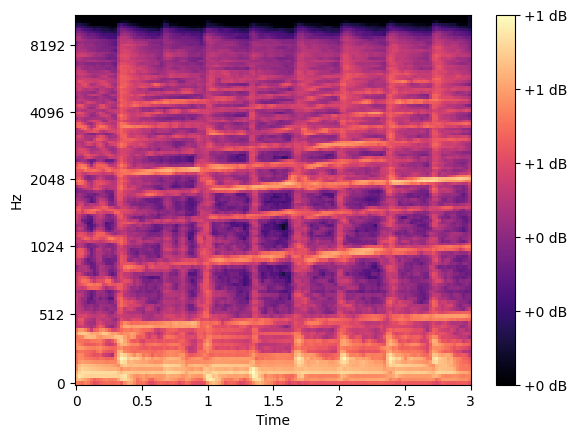

In [5]:
# Plot Mel Spectrogram to ensure proper data
librosa.display.specshow(data=X_train[0], y_axis='mel', x_axis='time')
plt.colorbar(format='%+2.0f dB')
plt.show()

In [7]:
# Check that shapes are correct for CNN
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6995, 128, 130)
(1496, 128, 130)
(1500, 128, 130)


In [8]:
# Add extra dimension for mono channel for CNN
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6995, 128, 130, 1)
(1496, 128, 130, 1)
(1500, 128, 130, 1)


In [9]:
# Save input shape for model
input_shape = X_train.shape[1:]
print(input_shape)

(128, 130, 1)


In [27]:
# Model Version One
# 3 Layer CNN with Max pooling

CNN_3_layer_Max_input = keras.Input(shape=input_shape, name="Mel_Spec")

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(CNN_3_layer_Max_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu") (x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu") (x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_3_layer_Max_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_3_layer_Max = keras.Model(CNN_3_layer_Max_input, CNN_3_layer_Max_output, name='3_Layer_Max')
CNN_3_layer_Max.summary()

Model: "3_Layer_Max"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,434 (6.35 MB)

 Trainable params: 1,663,114 (6.34 MB)

 Non-trainable params: 320 (1.25 KB)

In [28]:
# Compile model for training
CNN_3_layer_Max.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [29]:
# Create an early stopping callback
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=20, min_delta=0)

In [30]:
# Train Model
hist_3_layer = CNN_3_layer_Max.fit(
    X_train,
    y_train,
    epochs = 100,
    validation_data=(X_val, y_val),
    verbose=1,
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.1971 - loss: 2.2488 - val_accuracy: 0.1170 - val_loss: 7.3055
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3172 - loss: 1.9176 - val_accuracy: 0.1905 - val_loss: 8.4965
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3760 - loss: 1.7318 - val_accuracy: 0.3128 - val_loss: 3.8331
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4339 - loss: 1.6059 - val_accuracy: 0.4352 - val_loss: 2.1472
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4763 - loss: 1.5035 - val_accuracy: 0.4686 - val_loss: 1.8809
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5191 - loss: 1.3733 - val_accuracy: 0.5047 - val_loss: 1.8266
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5511 - loss: 1.2904 - val_accuracy: 0.5147 - val_loss: 1.5877
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5798 - loss: 1.2137 -

In [35]:
def plot_history(hist):
    """Plots the accuracy and loss for a model over the course of all epochs

    Parameters:
        hist (keras history object): The recorded history of model.fit() to be plotted
    """
    fig, axs = plt.subplots(2, 1, figsize=(8,7))
    fig.tight_layout(pad=2)

    # Accuracy subplot
    axs[0].plot(hist.history['accuracy'], c='navy', label="Training Accuracy")
    axs[0].plot(hist.history["val_accuracy"], c='orange', label="Validation Accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")
    axs[0].set_title("Accuracy")

    # Error subplot
    axs[1].plot(hist.history["loss"], c='navy', label="Training Loss")
    axs[1].plot(hist.history["val_loss"], c='orange', label="Validation Loss")
    axs[1].set_ylabel("Loss")
    axs[1].set_xlabel("Epochs")
    axs[1].legend(loc="upper right")
    axs[1].set_title("Loss")

    plt.show()

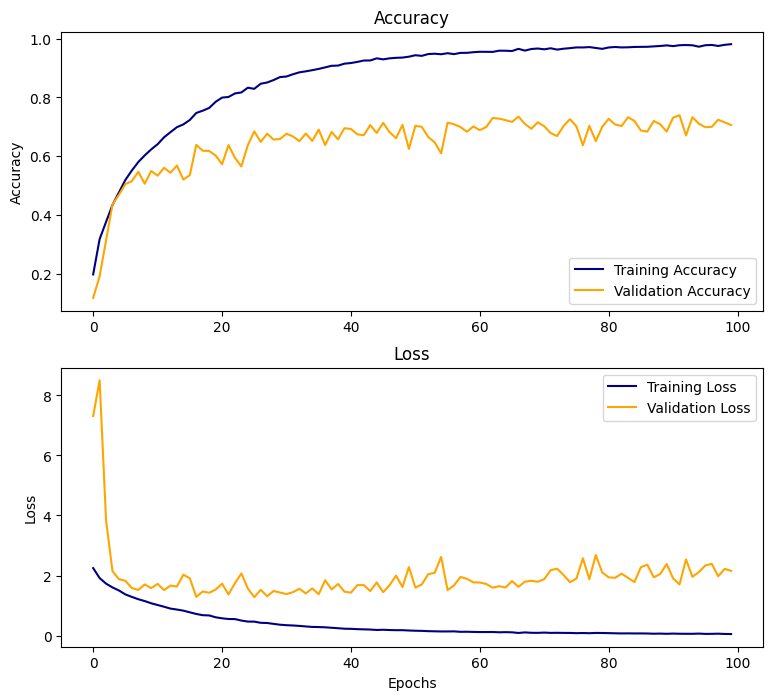

In [36]:
plot_history(hist_3_layer)

In [37]:
loss_cnn1, acc_cnn1 = CNN_3_layer_Max.evaluate(X_test, y_test)
print(f"Test Loss: {loss_cnn1}")
print(f"Test Accuracy: {acc_cnn1}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7307 - loss: 2.2207
Test Loss: 2.220747709274292
Test Accuracy: 0.7306666374206543


The graphs above show that the model is overfitting to the training data. Even though the accuracy and loss of the training data improves, the val accuracy and loss remains constant after only a few training epochs. This means that the model is memorizing the training data instead of recognizing general real world characteristics of the different genres.

In [42]:
# Add L2 Regularization to Model to combat overfitting

# Define the L2 strength
l2_strength = 0.001

# Model Version Two - Updated with L2 Regularization
CNN_2_input = layers.Input(shape=input_shape, name="Mel_Spec")

# Layer One
x = layers.Conv2D(32, kernel_size=(3, 3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(CNN_2_input)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Two
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Layer Three
x = layers.Conv2D(64, kernel_size=(3,3), activation="relu",
                  kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

# Flatten out to send through dense layers
x = layers.Flatten()(x)

# Dense Hidden Layer
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(l2_strength))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

# Final classification
CNN_2_output = layers.Dense(10, activation="softmax", name="Output")(x)

CNN_2 = keras.Model(CNN_2_input, CNN_2_output, name='CNN_2')
CNN_2.summary()

Model: "CNN_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Mel_Spec (InputLayer)           │ (None, 128, 130, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 126, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 61, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 28, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,946 (6.35 MB)

 Trainable params: 1,663,370 (6.35 MB)

 Non-trainable params: 576 (2.25 KB)

In [43]:
# Compile model for training
CNN_2.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [44]:
# Train Model
hist_2 = CNN_2.fit(
    X_train,
    y_train,
    epochs = 100,
    validation_data=(X_val, y_val),
    verbose=1,
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.3314 - loss: 2.5664 - val_accuracy: 0.1564 - val_loss: 9.8103
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.4832 - loss: 1.9309 - val_accuracy: 0.1076 - val_loss: 14.4846
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.5653 - loss: 1.6710 - val_accuracy: 0.2634 - val_loss: 4.4795
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6143 - loss: 1.5230 - val_accuracy: 0.3844 - val_loss: 3.1653
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6437 - loss: 1.4003 - val_accuracy: 0.4779 - val_loss: 2.5030
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6798 - loss: 1.3033 - val_accuracy: 0.4713 - val_loss: 2.5989
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7021 - loss: 1.2249 - val_accuracy: 0.4699 - val_loss: 2.4685
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7219 - loss: 1.1662 

In [45]:
loss_cnn2, acc_cnn2 = CNN_2.evaluate(X_test, y_test)
print(f"Test Loss: {loss_cnn1}")
print(f"Test Accuracy: {acc_cnn1}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7080 - loss: 1.8503
Test Loss: 2.220747709274292
Test Accuracy: 0.7306666374206543


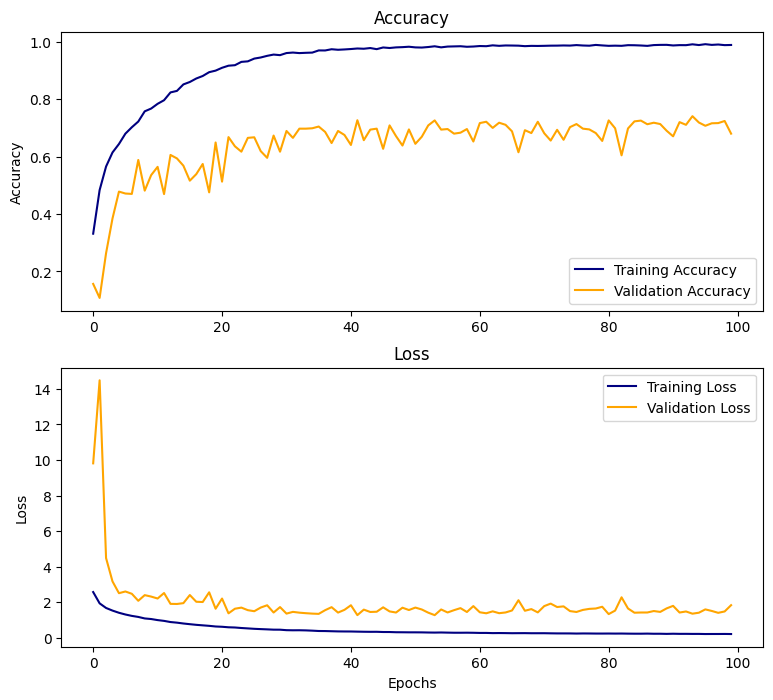

In [46]:
plot_history(hist_2)

In [48]:
from google.colab import drive
drive.mount('/content/drive')

CNN_2.save("/content/drive/MyDrive/CNN_2.keras")
print("Saved model to disk")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved model to disk
